In [192]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

# Loan Dataset

## Loading Loan Dataset

In [193]:
loan = pd.read_csv(r'loan-train.csv')

## EDA & Data Cleaning

In [194]:
loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# Loan Prediction Dataset - Feature Guide

```text
Loan_ID             : "Unique identifier for each applied loan application."
Gender              : "Gender of the applicant (Male or Female)."
Married             : "Marital status of the applicant (Yes or No)."
Dependents          : "Number of family members dependent on the applicant (0, 1, 2, 3+)."
Education           : "Educational qualification of the applicant (Graduate or Not Graduate)."
Self_Employed       : "Indicates if the applicant is self-employed or works a regular job (Yes or No)."
ApplicantIncome     : "The primary monthly income of the main loan applicant."
CoapplicantIncome   : "The monthly income of the co-applicant or guarantor (if any)."
LoanAmount          : "The total loan amount requested by the applicant (usually in thousands)."
Loan_Amount_Term    : "The repayment period or duration of the loan in terms of months."
Credit_History      : "Past credit history guidelines compliance score where 1.0 means good credit and 0.0 means bad credit."
Property_Area       : "The geographical location type where the property is located (Urban, Semiurban, or Rural)."
Loan_Status         : "The target variable indicating whether the loan was approved (Y) or rejected (N)."

In [195]:
print(f'rows = {loan.shape[0]} \ncolumns = {loan.shape[1]}'.title())

Rows = 1614 
Columns = 13


In [196]:
loan.duplicated().sum()

np.int64(0)

In [197]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1614 entries, 0 to 1613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            1614 non-null   object 
 1   Gender             1601 non-null   object 
 2   Married            1611 non-null   object 
 3   Dependents         1599 non-null   object 
 4   Education          1614 non-null   object 
 5   Self_Employed      1582 non-null   object 
 6   ApplicantIncome    1614 non-null   int64  
 7   CoapplicantIncome  1614 non-null   float64
 8   LoanAmount         1592 non-null   float64
 9   Loan_Amount_Term   1600 non-null   float64
 10  Credit_History     1564 non-null   float64
 11  Property_Area      1614 non-null   object 
 12  Loan_Status        1614 non-null   object 
dtypes: float64(4), int64(1), object(8)
memory usage: 164.1+ KB


In [198]:
loan.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,1614.000000,1614.000000,1592.000000,1600.000000,1564.00000
mean,8746.304833,3658.722999,218.846734,290.475000,0.63555
std,6249.885122,3291.745935,133.623293,81.899735,0.48143
min,150.000000,0.000000,9.000000,12.000000,0.00000
25%,3675.250000,986.250000,112.000000,240.000000,0.00000
50%,7045.000000,2941.500000,180.000000,360.000000,1.00000
75%,13251.000000,5893.000000,324.000000,360.000000,1.00000
max,81000.000000,41667.000000,700.000000,480.000000,1.00000


In [199]:
loan.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [200]:
loan_categorical_null = ['Gender', 'Married', 'Dependents', 'Self_Employed']
loan_numerical_null = ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']

In [201]:
for i in loan_categorical_null:
    loan[i].fillna(loan[i].mode()[0], inplace = True)
    print(f'{i} filling completed'.title())

Gender Filling Completed
Married Filling Completed
Dependents Filling Completed
Self_Employed Filling Completed


In [202]:
px.box(loan[loan_numerical_null], points = 'suspectedoutliers').show()

##### As we analyze that outlier is'nt that far from upper fence or lower fence so, we wiil fill out null values with mean

In [203]:
for i in loan_numerical_null:
    loan[i].fillna(loan[i].mean(), inplace = True)
    print(f'{i} filling completed'.title())

Loanamount Filling Completed
Loan_Amount_Term Filling Completed
Credit_History Filling Completed


In [204]:
loan.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

### Outliers Handling Using IQR Method

In [205]:
numerical_col = loan.select_dtypes([int, float])
numerical_col.drop(['Credit_History', 'LoanAmount', 'Loan_Amount_Term'], axis = 1, inplace = True)
px.box(numerical_col, points = 'suspectedoutliers').show()

In [206]:
numerical_col = numerical_col.columns

for col in numerical_col:
    Q1 = loan[col].quantile(0.25)
    Q3 = loan[col].quantile(0.75)

    IQR = Q3 - Q1

    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR

    loan[col] = loan[col].clip(lower = lower_bound, upper = upper_bound)
    print(f'{col} Done')    

ApplicantIncome Done
CoapplicantIncome Done


In [207]:
numerical_col = loan.select_dtypes([int, float])
numerical_col.drop(['Credit_History', 'LoanAmount', 'Loan_Amount_Term'], axis = 1, inplace = True)
px.box(numerical_col, points = 'suspectedoutliers').show()

In [208]:
loan.drop(columns = ['Loan_ID'], axis = 1, inplace = True)

In [209]:
loan.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849.0,0.0,218.846734,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583.0,1508.0,128.000000,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.000000,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.000000,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000.0,0.0,141.000000,360.0,1.0,Urban,Y


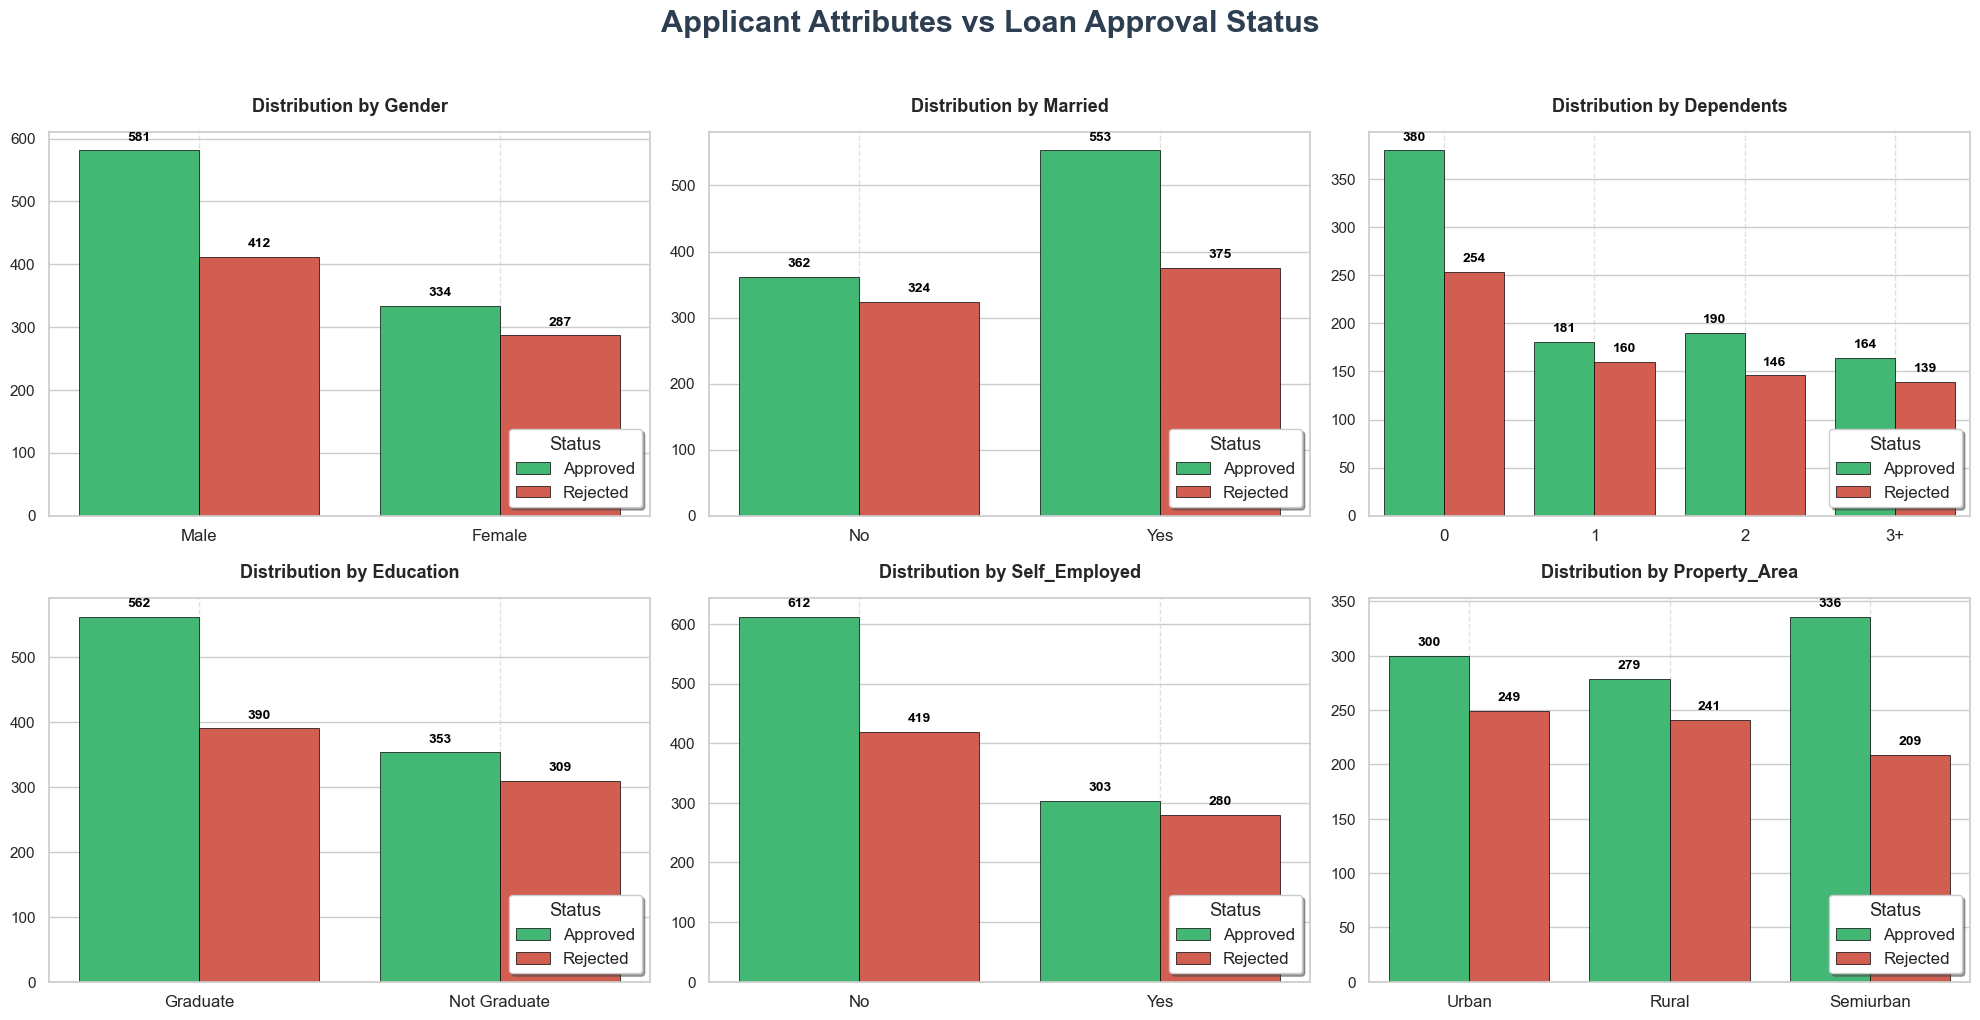

In [210]:
sns.set_theme(style = "whitegrid")
sns.set_context("notebook", font_scale = 1.1, rc = {"lines.linewidth": 2.5})

status_palette = {
    'Y': '#2ECC71',
    'N': '#E74C3C'
}

fig, axes = plt.subplots(2, 3, figsize = (20, 10))
axes = axes.flatten()

columns = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

for i, col in enumerate(columns):
    ax = axes[i]
    
    sns.countplot(
        x = loan[col],
        hue = loan['Loan_Status'],
        palette = status_palette,
        ax = ax,
        edgecolor = 'black',     
        linewidth = 0.5
    )
    
    for container in ax.containers:
        ax.bar_label(container, padding = 5, size = 10, weight = 'bold', color = 'black')
    
    ax.set_title(f"Distribution by {col}", fontsize = 13, weight = 'semibold', pad = 15)
    ax.set_ylabel("")                           
    ax.set_xlabel("")                           
    ax.tick_params(axis = 'y', labelsize = 11)      
    ax.grid(axis = 'x', linestyle = '--', alpha = 0.6) 
    
    # Customize Legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ['Approved', 'Rejected'], title = 'Status', 
              frameon = True, fancybox = True, shadow = True, loc = 'lower right')


fig.suptitle("Applicant Attributes vs Loan Approval Status", 
             fontsize = 22, weight = 'bold', y = 1.02, color = '#2C3E50')
plt.tight_layout()
plt.show()

In [211]:
loan.nunique()

Gender                  2
Married                 2
Dependents              4
Education               2
Self_Employed           2
ApplicantIncome      1449
CoapplicantIncome    1204
LoanAmount            462
Loan_Amount_Term       11
Credit_History          3
Property_Area           3
Loan_Status             2
dtype: int64

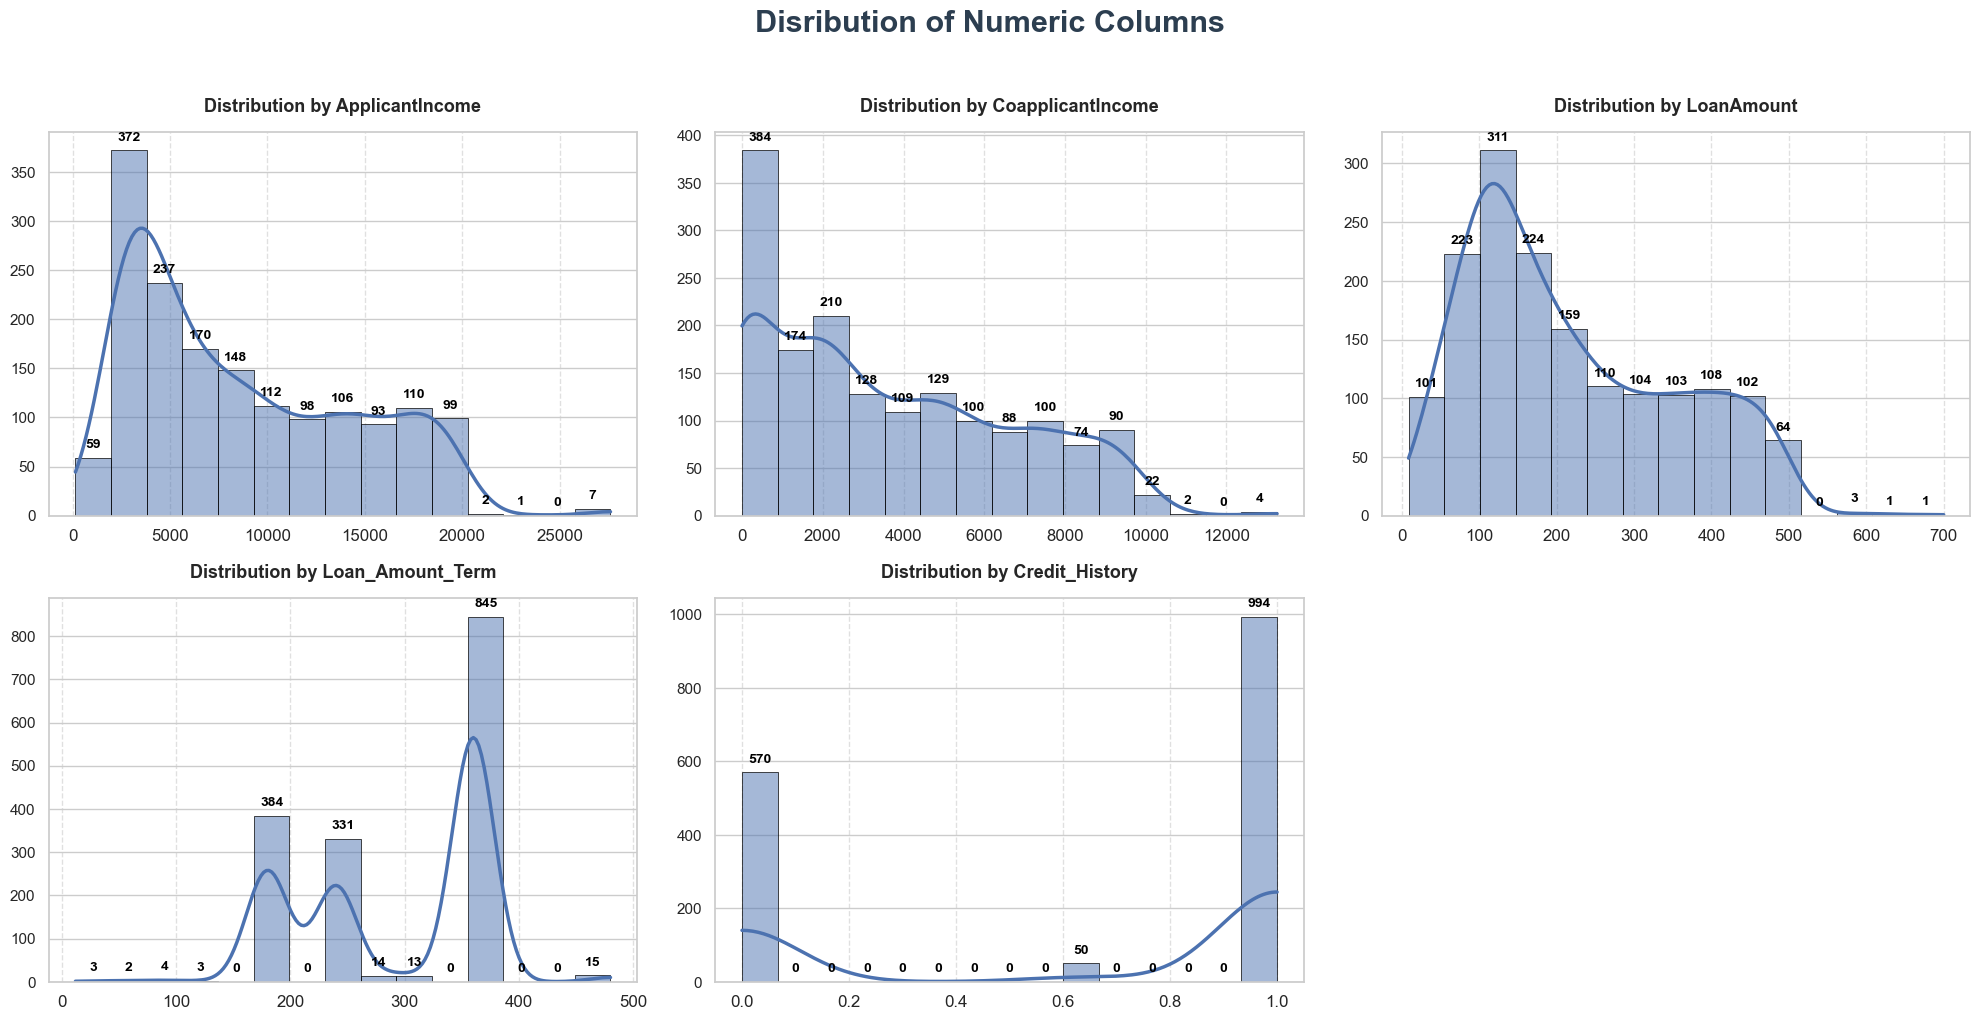

In [212]:
sns.set_theme(style = "whitegrid")
sns.set_context("notebook", font_scale = 1.1, rc = {"lines.linewidth": 2.5})

status_palette = {
    'Y': '#2ECC71',
    'N': '#E74C3C'
}

fig, axes = plt.subplots(2, 3, figsize = (20, 10))
axes = axes.flatten()

columns = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

for i, col in enumerate(columns):
    ax = axes[i]
    
    sns.histplot(
        x = loan[col],
        ax = ax,
        edgecolor = 'black',     
        linewidth = 0.5,
        kde = True,
        bins = 15
    )
    
    for container in ax.containers:
        ax.bar_label(container, padding = 5, size = 10, weight = 'bold', color = 'black')
    
    ax.set_title(f"Distribution by {col}", fontsize = 13, weight = 'semibold', pad = 15)
    ax.set_ylabel("")                           
    ax.set_xlabel("")                           
    ax.tick_params(axis = 'y', labelsize = 11)      
    ax.grid(axis = 'x', linestyle = '--', alpha = 0.6) 

axes[5].set_visible(False)

fig.suptitle("Disribution of Numeric Columns", 
             fontsize = 22, weight = 'bold', y = 1.02, color = '#2C3E50')
plt.tight_layout()
plt.show()

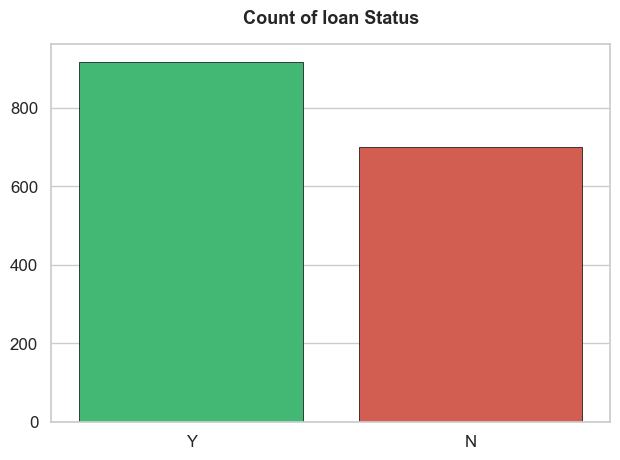

In [213]:
sns.set_theme(style = "whitegrid")
sns.set_context("notebook", font_scale = 1.1, rc = {"lines.linewidth": 2.5})

sns.countplot(
        x = loan['Loan_Status'],
        hue = loan['Loan_Status'],
        palette = status_palette,
        edgecolor = 'black',     
        linewidth = 0.5
    )
    
plt.title(f"Count of loan Status", fontsize = 13, weight = 'semibold', pad = 15)
plt.xlabel("")                           
plt.ylabel("")                           

plt.tight_layout()
plt.show()

In [214]:
px.parallel_coordinates(loan[[
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'Loan_Amount_Term'
]], color = 'LoanAmount').show()

In [215]:
fig = px.sunburst(
    loan,
    path = ['Property_Area', 'Married', 'Education', 'Gender'],
    values = loan['LoanAmount'],
)

fig.update_layout(
    title = dict(
        text = "<b>Loan Amount Distribution</b><br><sup>Hierarchy: Property Area → Marriage → Education → Gender</sup>",
        font = dict(size = 18, color = '#2C3E50')
    ),
    width = 750,   
    height = 650,
)

fig.update_traces(
    hovertemplate = '<b>%{label}</b><br>' +
                  'Total Loan: ₹%{value:,.0f}<br>' +
                  'Parent Share: %{percentParent:.1%}<br>' +
                  'Overall Share: %{percentRoot:.1%}<extra></extra>'
)

fig.show()  

In [216]:
loan.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849.0,0.0,218.846734,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583.0,1508.0,128.000000,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.000000,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.000000,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000.0,0.0,141.000000,360.0,1.0,Urban,Y


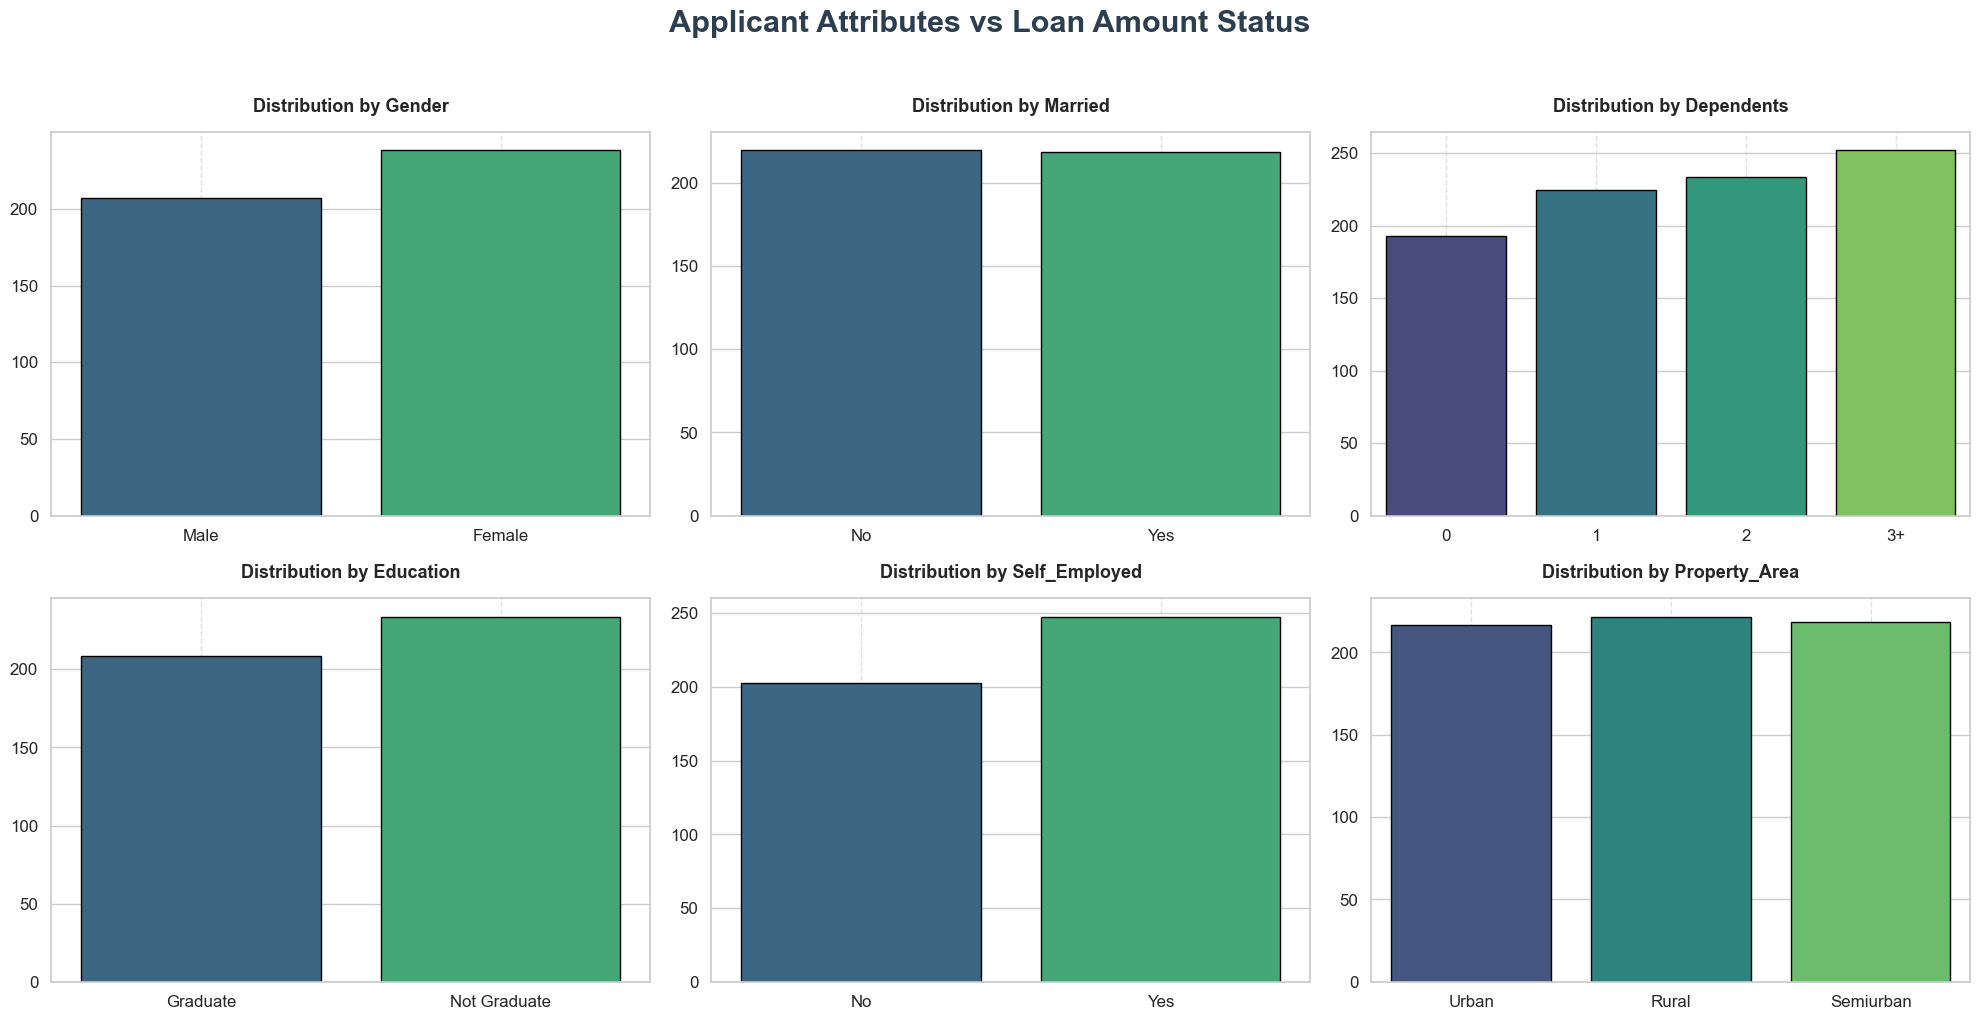

In [217]:
sns.set_theme(style = "whitegrid")
sns.set_context("notebook", font_scale = 1.1, rc = {"lines.linewidth": 2.5})

fig, axes = plt.subplots(2, 3, figsize = (20, 10))
axes = axes.flatten()

columns = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

for i, col in enumerate(columns):
    ax = axes[i]
    
    sns.barplot(
        x = loan[col],
        y = loan['LoanAmount'],
        ax = ax,
        edgecolor = 'black',
        errorbar = None,
        palette = 'viridis'
    )
    
    
    ax.set_title(f"Distribution by {col}", fontsize = 13, weight = 'semibold', pad = 15)
    ax.set_ylabel("")                           
    ax.set_xlabel("")                               
    ax.grid(axis = 'x', linestyle = '--', alpha = 0.6) 


fig.suptitle("Applicant Attributes vs Loan Amount Status", 
             fontsize = 22, weight = 'bold', y = 1.02, color = '#2C3E50')
plt.tight_layout()
plt.show()

In [218]:
px.scatter(x = loan['LoanAmount'], color = loan['Property_Area']).show()

In [219]:
sample = loan.sample(500).reset_index()

fig = px.line(
    sample, 
    x = sample.index,        
    y = 'LoanAmount',    
    title = 'Loan Amount Distribution Over Dataset (Row-wise)',
    labels = {'index': 'Data Point (Row Number)', 'LoanAmount': 'Loan Amount (in thousands)'},
    color = 'Gender',
    height = 500,
    width = 900
)
fig.show()

In [220]:
fig = px.line(
    sample.sort_values('ApplicantIncome'),  
    x = 'ApplicantIncome', 
    y = 'LoanAmount',
    title = 'Loan Amount vs Applicant Income (Trend)',
    color = 'Education',
    height = 500,
    width = 900
)
fig.show()

In [221]:
avg_loan = loan.groupby(['Property_Area', 'Education'])['LoanAmount'].mean().reset_index()

fig3 = px.line(
    avg_loan, 
    x = 'Property_Area', 
    y = 'LoanAmount', 
    color = 'Education',
    title = 'Average Loan Amount by Education',
    markers = True,
    height = 500,
    width = 900
)
fig3.show()

# Adult Dataset

## Loading Dataset

In [222]:
df_adult = pd.read_csv(r'adult.csv')

## EDA & Data Cleaning

In [223]:
df_adult.head(3)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


In [224]:
print(f'rows = {df_adult.shape[0]} \ncolumns = {df_adult.shape[1]}'.title())

Rows = 48842 
Columns = 15


In [225]:
df_adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [226]:
df_adult.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [227]:
df_adult.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [228]:
df_adult.duplicated().sum()

np.int64(52)

In [229]:
df_adult.drop_duplicates(inplace = True)

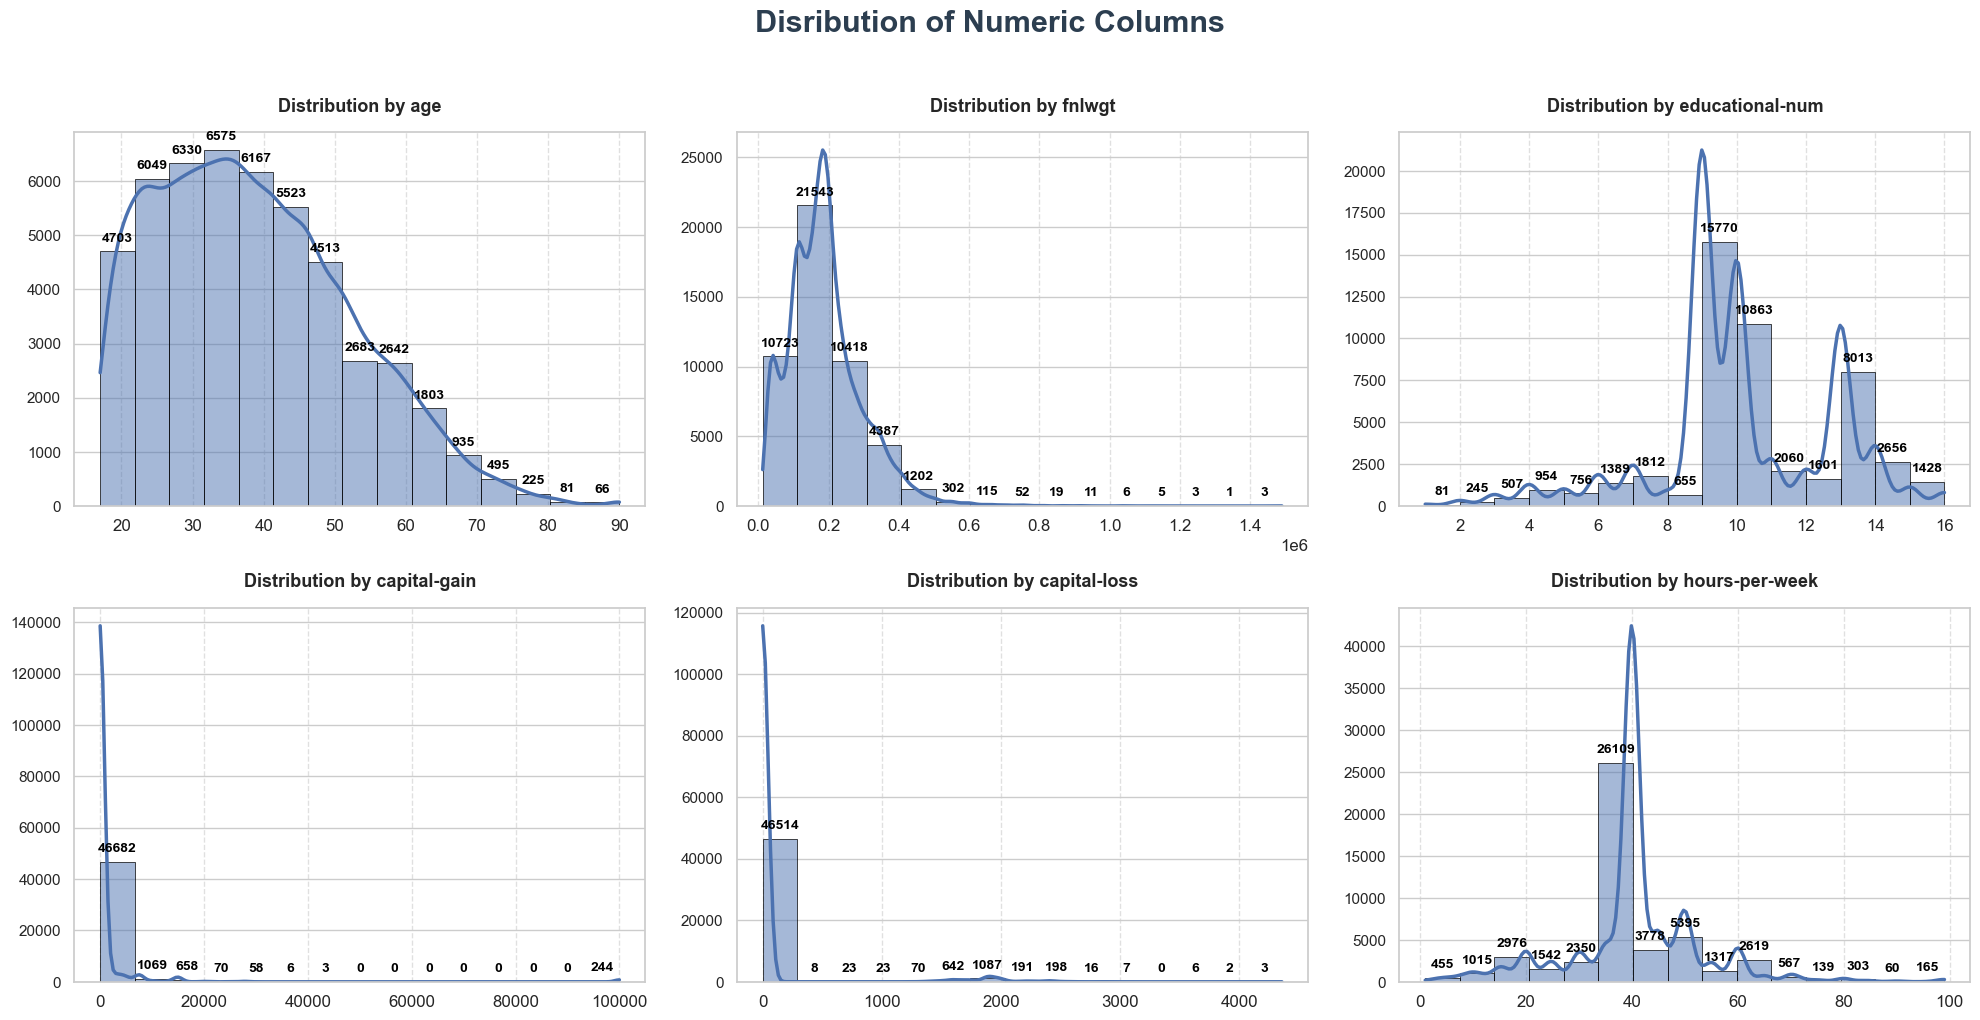

In [230]:
sns.set_theme(style = "whitegrid")
sns.set_context("notebook", font_scale = 1.1, rc = {"lines.linewidth": 2.5})


fig, axes = plt.subplots(2, 3, figsize = (20, 10))
axes = axes.flatten()

columns = df_adult.select_dtypes(int)

for i, col in enumerate(columns):
    ax = axes[i]
    
    sns.histplot(
        x = df_adult[col],
        ax = ax,
        edgecolor = 'black',     
        linewidth = 0.5,
        kde = True,
        bins = 15
    )
    
    for container in ax.containers:
        ax.bar_label(container, padding = 5, size = 10, weight = 'bold', color = 'black')
    
    ax.set_title(f"Distribution by {col}", fontsize = 13, weight = 'semibold', pad = 15)
    ax.set_ylabel("")                           
    ax.set_xlabel("")                           
    ax.tick_params(axis = 'y', labelsize = 11)      
    ax.grid(axis = 'x', linestyle = '--', alpha = 0.6)

fig.suptitle("Disribution of Numeric Columns", 
             fontsize = 22, weight = 'bold', y = 1.02, color = '#2C3E50')
plt.tight_layout()
plt.show()

In [231]:
df_adult['income'].unique()

array(['<=50K', '>50K'], dtype=object)

In [232]:
df_adult['is_>50K_income'] = df_adult['income'].map({
    '<=50K' : 'No',
    '>50K' : 'Yes',
})

In [233]:
df_adult.drop(columns = 'income', axis = 1, inplace = True)

In [234]:
df_adult.head(3)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,is_>50K_income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,No
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,No
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,Yes


In [235]:
x = df_adult['is_>50K_income'].value_counts().values
y = df_adult['is_>50K_income'].value_counts().index

px.bar(
    df_adult,
    x = x,
    y = y,
    title = 'Count of (is_>50K_income)',
    labels = {
        'x' : 'Counts',
        'y' : 'Is income is >'
    }
)

In [236]:
df_adult.dtypes

age                 int64
workclass          object
fnlwgt              int64
education          object
educational-num     int64
marital-status     object
occupation         object
relationship       object
race               object
gender             object
capital-gain        int64
capital-loss        int64
hours-per-week      int64
native-country     object
is_>50K_income     object
dtype: object

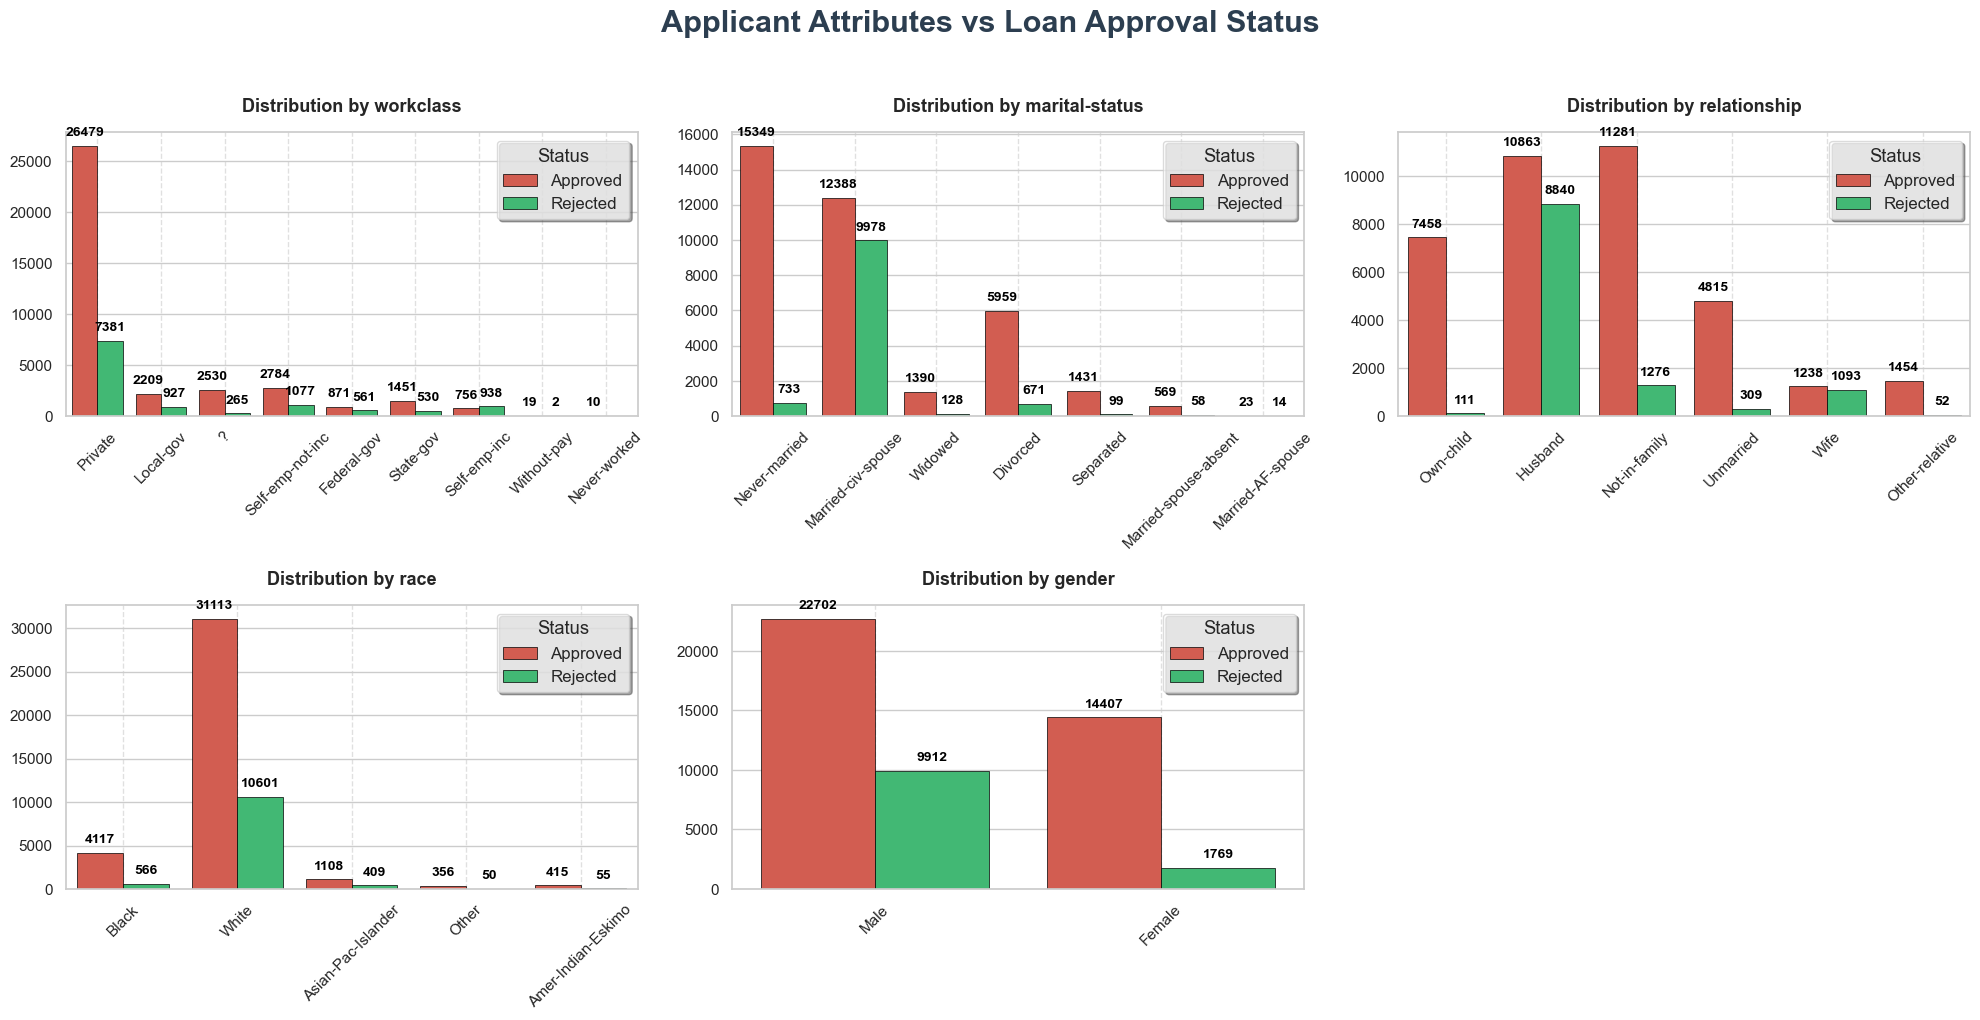

In [237]:
sns.set_theme(style = "whitegrid")
sns.set_context("notebook", font_scale = 1.1, rc = {"lines.linewidth": 2.5})

status_palette = {
    'Yes': '#2ECC71',
    'No': '#E74C3C'
}

fig, axes = plt.subplots(2, 3, figsize = (20, 10))
axes = axes.flatten()

columns = df_adult.select_dtypes(object).drop(columns = ['is_>50K_income', 'native-country', 'education', 'occupation'], axis = 1)

for i, col in enumerate(columns):
    ax = axes[i]
    
    sns.countplot(
        x = df_adult[col],
        hue = df_adult['is_>50K_income'],
        palette = status_palette,
        ax = ax,
        edgecolor = 'black',     
        linewidth = 0.5
    )
    
    for container in ax.containers:
        ax.bar_label(container, padding = 5, size = 10, weight = 'bold', color = 'black')
    
    ax.set_title(f"Distribution by {col}", fontsize = 13, weight = 'semibold', pad = 15)
    ax.set_ylabel("")                           
    ax.set_xlabel("")                           
    ax.tick_params(axis = 'y', labelsize = 11)      
    ax.tick_params(axis='x', rotation = 45, labelsize = 11)
    ax.grid(axis = 'x', linestyle = '--', alpha = 0.6) 
    
    # Customize Legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ['Approved', 'Rejected'], title = 'Status', 
              frameon = True, fancybox = True, shadow = True, loc = 'upper right', framealpha = 0.7)

axes[5].set_visible(False)


fig.suptitle("Applicant Attributes vs Loan Approval Status", 
             fontsize = 22, weight = 'bold', y = 1.02, color = '#2C3E50')
plt.tight_layout()
plt.show()

In [238]:
columns = ['native-country', 'education', 'occupation']


print('Unique \n\n')
for i in columns:
    print(f' {i} = {df_adult[i].unique()} \n')


print('No of unique \n\n')
for i in columns:
    print(f' {i} = {df_adult[i].nunique()} \n')

Unique 


 native-country = ['United-States' '?' 'Peru' 'Guatemala' 'Mexico' 'Dominican-Republic'
 'Ireland' 'Germany' 'Philippines' 'Thailand' 'Haiti' 'El-Salvador'
 'Puerto-Rico' 'Vietnam' 'South' 'Columbia' 'Japan' 'India' 'Cambodia'
 'Poland' 'Laos' 'England' 'Cuba' 'Taiwan' 'Italy' 'Canada' 'Portugal'
 'China' 'Nicaragua' 'Honduras' 'Iran' 'Scotland' 'Jamaica' 'Ecuador'
 'Yugoslavia' 'Hungary' 'Hong' 'Greece' 'Trinadad&Tobago'
 'Outlying-US(Guam-USVI-etc)' 'France' 'Holand-Netherlands'] 

 education = ['11th' 'HS-grad' 'Assoc-acdm' 'Some-college' '10th' 'Prof-school'
 '7th-8th' 'Bachelors' 'Masters' 'Doctorate' '5th-6th' 'Assoc-voc' '9th'
 '12th' '1st-4th' 'Preschool'] 

 occupation = ['Machine-op-inspct' 'Farming-fishing' 'Protective-serv' '?'
 'Other-service' 'Prof-specialty' 'Craft-repair' 'Adm-clerical'
 'Exec-managerial' 'Tech-support' 'Sales' 'Priv-house-serv'
 'Transport-moving' 'Handlers-cleaners' 'Armed-Forces'] 

No of unique 


 native-country = 42 

 education = 16 

 

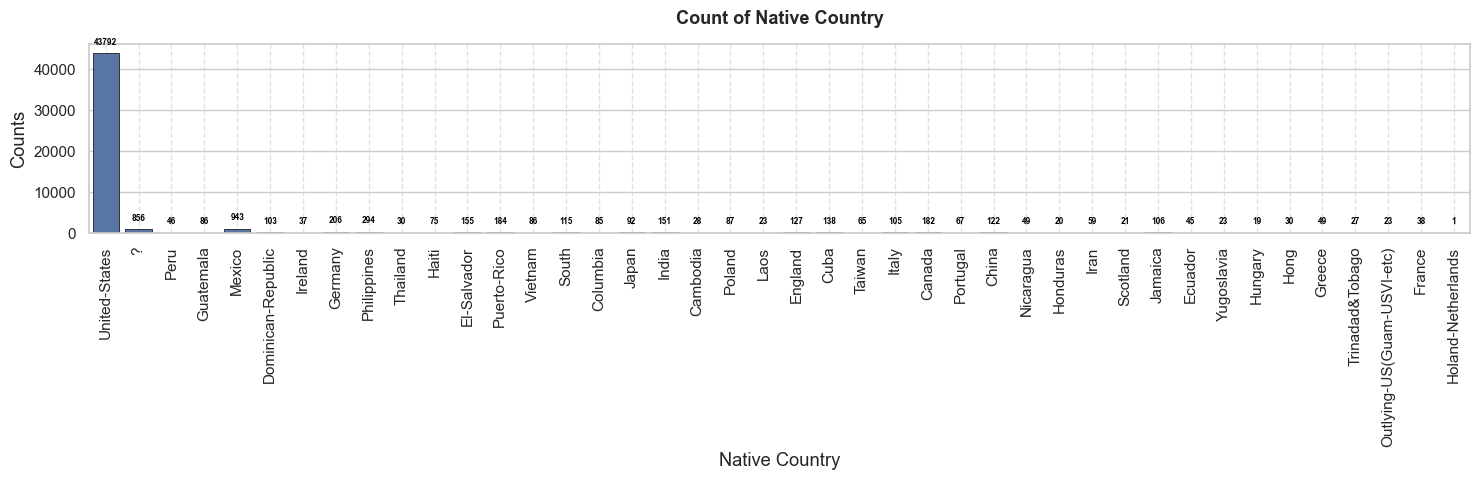

In [239]:
sns.set_theme(style = "whitegrid")
sns.set_context("notebook", font_scale = 1.1, rc = {"lines.linewidth": 2.5})
plt.figure(figsize = (15, 5))

ax = sns.countplot(
        x = df_adult['native-country'],
        edgecolor = 'black',     
        linewidth = 0.5
    )
    
for container in ax.containers:
    ax.bar_label(container, padding = 5, size = 6, weight = 'bold', color = 'black')
    
ax.set_title(f"Count of Native Country", fontsize = 13, weight = 'semibold', pad = 15)
ax.set_ylabel("Counts")                           
ax.set_xlabel("Native Country")                           
ax.tick_params(axis = 'y', labelsize = 11)      
ax.tick_params(axis = 'x', rotation = 90, labelsize = 11)
ax.grid(axis = 'x', linestyle = '--', alpha = 0.6) 

plt.tight_layout()
plt.show()

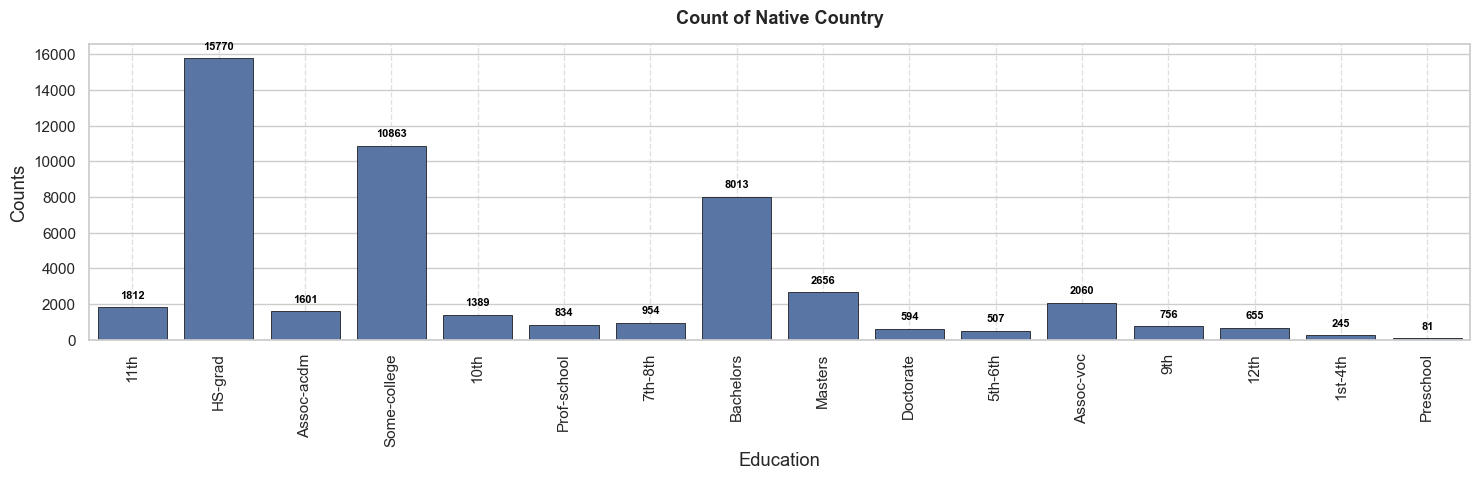

In [240]:
sns.set_theme(style = "whitegrid")
sns.set_context("notebook", font_scale = 1.1, rc = {"lines.linewidth": 2.5})
plt.figure(figsize = (15, 5))

ax = sns.countplot(
        x = df_adult['education'],
        edgecolor = 'black',     
        linewidth = 0.5
    )
    
for container in ax.containers:
    ax.bar_label(container, padding = 5, size = 8, weight = 'bold', color = 'black')
    
ax.set_title(f"Count of Native Country", fontsize = 13, weight = 'semibold', pad = 15)
ax.set_ylabel("Counts")                           
ax.set_xlabel("Education")                           
ax.tick_params(axis = 'y', labelsize = 11)      
ax.tick_params(axis = 'x', rotation = 90, labelsize = 11)
ax.grid(axis = 'x', linestyle = '--', alpha = 0.6) 

plt.tight_layout()
plt.show()

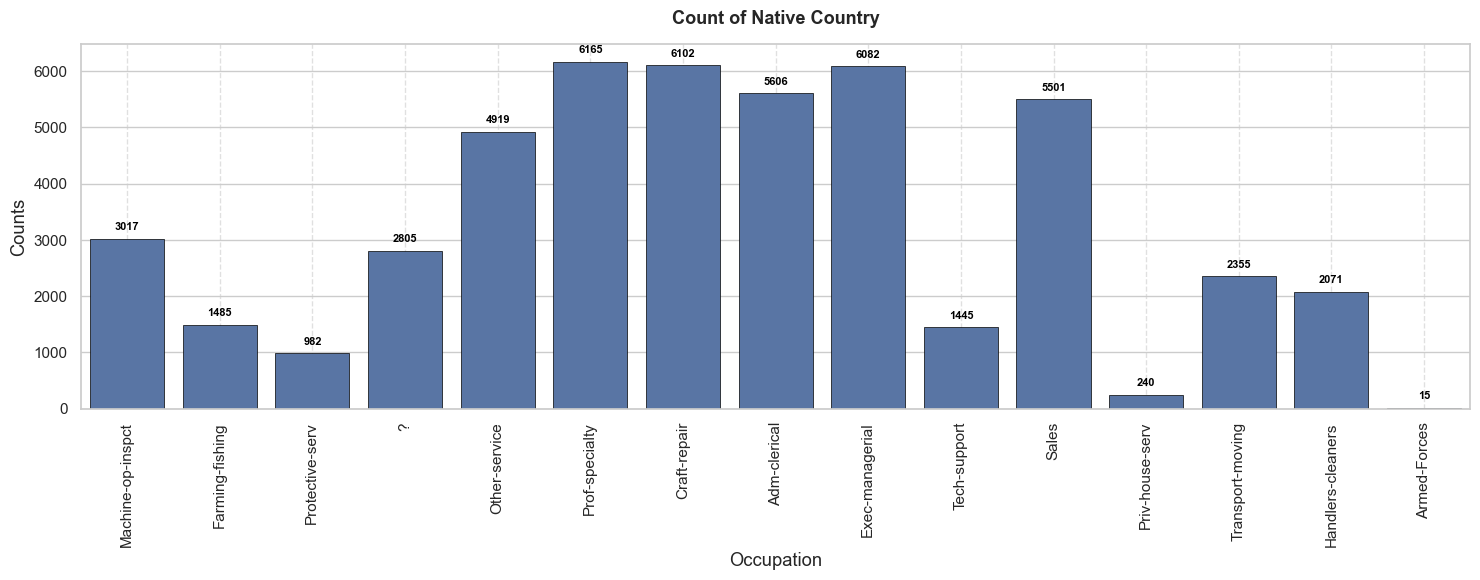

In [241]:
sns.set_theme(style = "whitegrid")
sns.set_context("notebook", font_scale = 1.1, rc = {"lines.linewidth": 2.5})
plt.figure(figsize = (15, 6))

ax = sns.countplot(
        x = df_adult['occupation'],
        edgecolor = 'black',     
        linewidth = 0.5
    )
    
for container in ax.containers:
    ax.bar_label(container, padding = 5, size = 8, weight = 'bold', color = 'black')
    
ax.set_title(f"Count of Native Country", fontsize = 13, weight = 'semibold', pad = 15)
ax.set_ylabel("Counts")                           
ax.set_xlabel("Occupation")                           
ax.tick_params(axis = 'y', labelsize = 11)      
ax.tick_params(axis = 'x', rotation = 90, labelsize = 11)
ax.grid(axis = 'x', linestyle = '--', alpha = 0.6) 

plt.tight_layout()
plt.show()

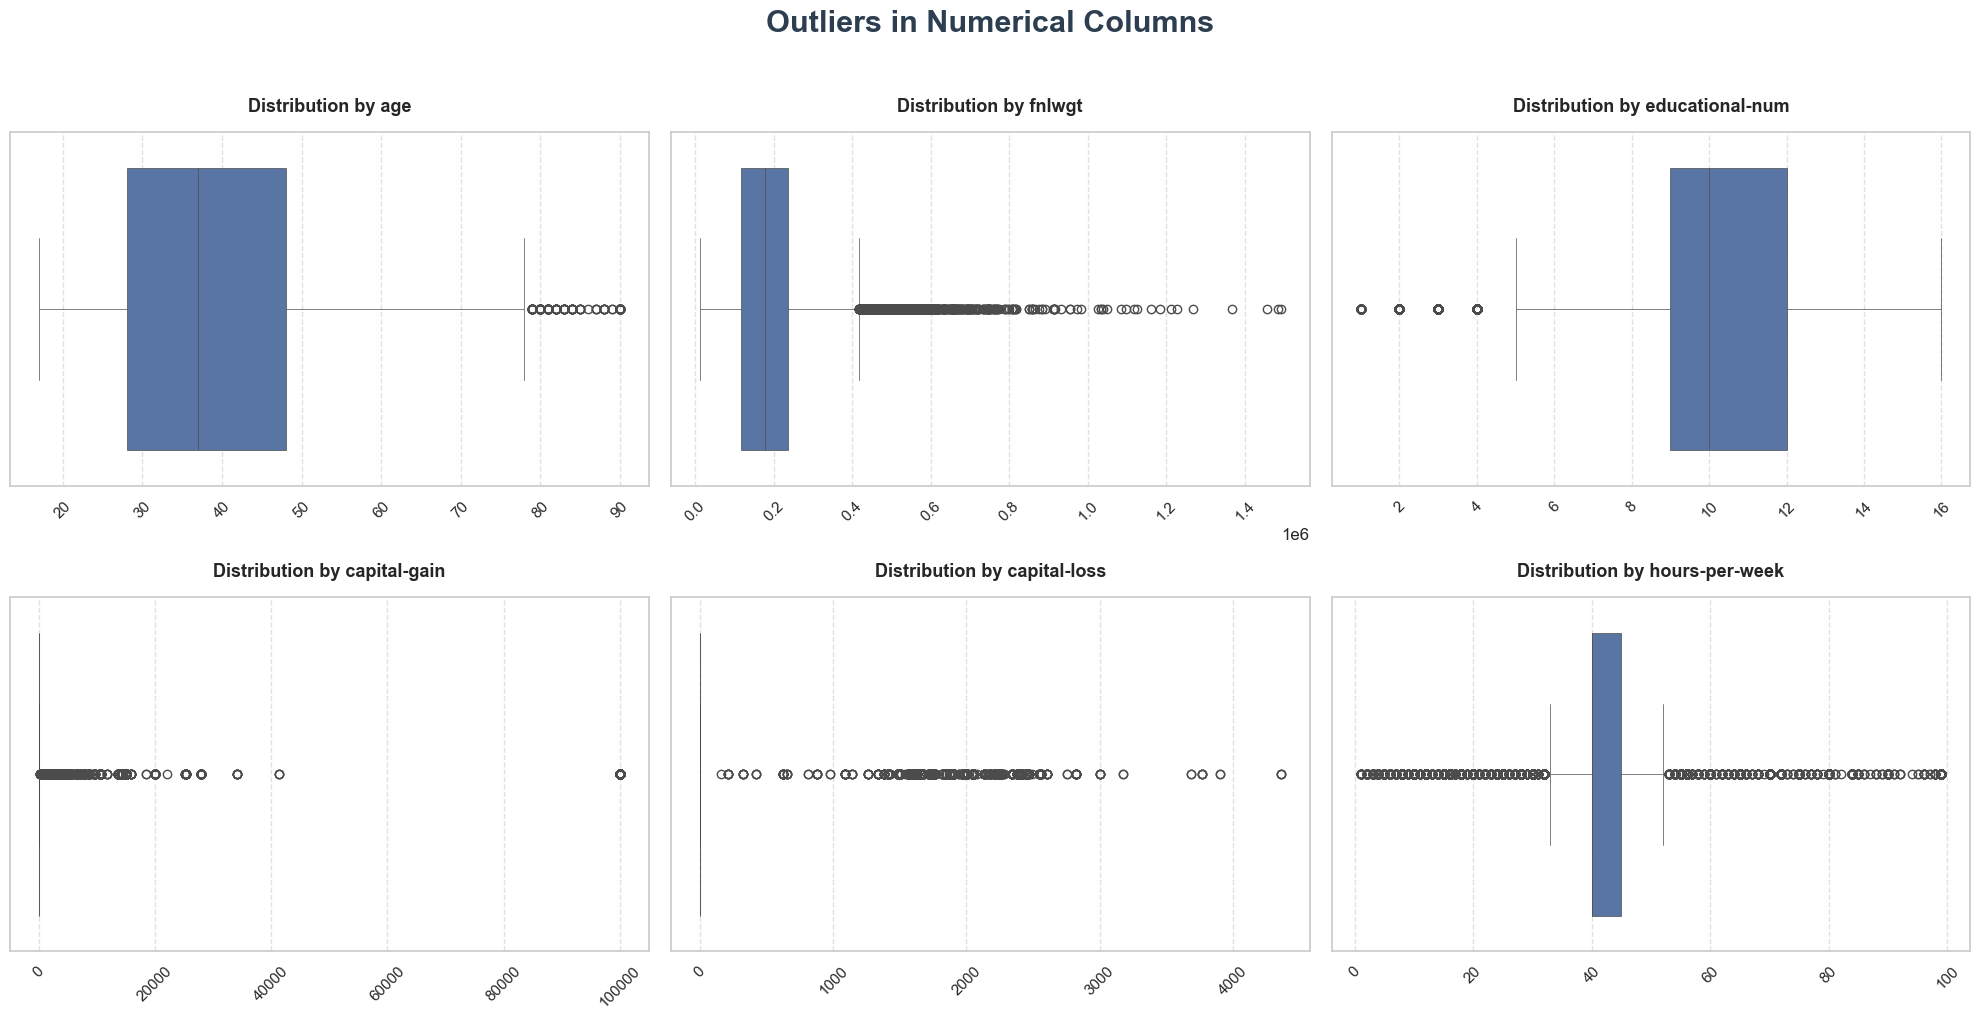

In [242]:
sns.set_theme(style = "whitegrid")
sns.set_context("notebook", font_scale = 1.1, rc = {"lines.linewidth": 2.5})


fig, axes = plt.subplots(2, 3, figsize = (20, 10))
axes = axes.flatten()

columns = df_adult.select_dtypes(int)

for i, col in enumerate(columns):
    ax = axes[i]
    
    sns.boxplot(
        x = df_adult[col],
        ax = ax,
        linewidth = 0.5
    )
    
    
    ax.set_title(f"Distribution by {col}", fontsize = 13, weight = 'semibold', pad = 15)
    ax.set_ylabel("")                           
    ax.set_xlabel("")                           
    ax.tick_params(axis = 'y', labelsize = 11)      
    ax.tick_params(axis='x', rotation = 45, labelsize = 11)
    ax.grid(axis = 'x', linestyle = '--', alpha = 0.6) 


fig.suptitle("Outliers in Numerical Columns", 
             fontsize = 22, weight = 'bold', y = 1.02, color = '#2C3E50')
plt.tight_layout()
plt.show()